 # Tentativo Simple CNN 

 -Inserire descrizione di cosa faremo in questo notebook-

## Import

## Fase 0

### Caricamento Dataset Split

In [ ]:
# Assicuriamoci di usare lo stesso CSV appena creato
OUTPUT_CSV = './waste_type_identification/train_val_split.csv'

# Ricarichiamo i dataframe dal CSV
try:
    df = pd.read_csv(OUTPUT_CSV)
    train_df = df[df['split'] == 'train']
    val_df = df[df['split'] == 'val']
    print(f"✅ CSV caricato con successo. Train set: {len(train_df)}, Val set: {len(val_df)}")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ ERRORE: Non trovo il file {OUTPUT_CSV}. Sicuro che la FASE 1 sia andata a buon fine?")

🚀 FASI 2, 3 e 4: Addestramento Baseline 🚀

✅ CSV caricato con successo. Train set: 12412, Val set: 3103

--- FASE 2: Caricamento tensori ---
✅ Immagini in memoria e pronte per la rete!

--- FASE 3: Architettura Rete ---
✅ Modello creato. Utilizzo acceleratore: CPU


### Resize Immagini

In [ ]:
print("\n--- FASE 2: Caricamento tensori ---")

# Trasformazioni base: ridimensionamento a 128x128 per velocità
base_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class WasteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self): 
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['filepath']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label']
        if self.transform: image = self.transform(image)
        return image, label

BATCH_SIZE = 16 
train_loader = DataLoader(WasteDataset(train_df, transform=base_transforms), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WasteDataset(val_df, transform=base_transforms), batch_size=BATCH_SIZE, shuffle=False)
print("✅ Immagini in memoria e pronte per la rete!")

### Costruzione CNN e addestramento

In [ ]:
print("\n--- FASE 3: Architettura Rete ---")

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 8) 

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)
        x = x.view(-1, 64 * 16 * 16)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Cerca prima una GPU NVIDIA (Windows/Linux), poi una GPU Mac, altrimenti usa la CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ Modello creato. Utilizzo acceleratore: {device.type.upper()}")

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from PIL import Image

print("🚀 MIVIA DAY 2 & 3: Valutazione Comparativa (Train vs Validation) 🚀\n")

class_names = ['Battery', 'Clothing', 'Glass', 'Metal', 'Organic', 'Papery', 'Plastic', 'Undiff']
model.eval()

# Creiamo un loader di training "pulito" (senza shuffle e senza augmentation) solo per la valutazione
train_eval_loader = DataLoader(WasteDataset(train_df, transform=val_transforms), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# FASE 4.1: VALUTAZIONE SUL TRAINING SET
# ==========================================
print("🏋️ Analisi del Training Set in corso...")
train_vere = []
train_predette = []

with torch.no_grad():
    for inputs, labels in train_eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        train_vere.extend(labels.cpu().numpy())
        train_predette.extend(predicted.cpu().numpy())

accuracy_bal_train = balanced_accuracy_score(train_vere, train_predette)
matrice_conf_train = confusion_matrix(train_vere, train_predette)

# ==========================================
# FASE 4.2: VALUTAZIONE SUL VALIDATION SET
# ==========================================
print("🧪 Analisi del Validation Set in corso...")
val_vere = []
val_predette = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        val_vere.extend(labels.cpu().numpy())
        val_predette.extend(predicted.cpu().numpy())

accuracy_bal_val = balanced_accuracy_score(val_vere, val_predette)
matrice_conf_val = confusion_matrix(val_vere, val_predette)

# ==========================================
# FASE 4.3: STAMPA CONFRONTO DIRETTO
# ==========================================
print("\n" + "="*40)
print("📊 VERDETTO FINALE DEL MODELLO")
print("="*40)
print(f"🏆 BALANCED ACCURACY TRAIN:      {accuracy_bal_train * 100:.2f}%")
print(f"🏆 BALANCED ACCURACY VALIDATION: {accuracy_bal_val * 100:.2f}%")
print("="*40)

# Grafico delle due Matrici di Confusione affiancate
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Mappa del Training
sns.heatmap(matrice_conf_train, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Matrice di Confusione - TRAINING SET', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predizione', fontsize=12)
axes[0].set_ylabel('Classe Vera', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Mappa del Validation
sns.heatmap(matrice_conf_val, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Matrice di Confusione - VALIDATION SET', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predizione', fontsize=12)
axes[1].set_ylabel('Classe Vera', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# FASE 4.4: VISUALIZZAZIONE ERRORI CRITICI (VALIDATION)
# ==========================================
indici_errori = [i for i in range(len(val_vere)) if val_vere[i] != val_predette[i]]
print(f"\n🔍 Analisi degli errori sul Validation Set ({len(indici_errori)} errori totali):")

if len(indici_errori) > 0:
    print("Mostro i primi 4 campioni falliti per l'analisi del report:\n")
    val_df_reset = val_df.reset_index(drop=True)
    fig, axes = plt.subplots(1, min(4, len(indici_errori)), figsize=(16, 4))
    if len(indici_errori) == 1: axes = [axes]
    
    for ax, idx in zip(axes, indici_errori[:4]):
        img_path = val_df_reset.iloc[idx]['filepath']
        vera_label = class_names[val_vere[idx]]
        pred_label = class_names[val_predette[idx]]
        
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Vera: {vera_label}\nPredetta: {pred_label}", 
                     color='red', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Monitoraggio VRAM Risorse MIVIA/Colab
if torch.cuda.is_available():
    vram_usata = torch.cuda.max_memory_allocated() / (1024 * 1024)
    print(f"\n💻 VRAM massima allocata sul dispositivo: {vram_usata:.2f} MB")


--- FASE 4: Addestramento ---
Inizio ciclo di 2 epoche...
  Epoca [1/2], Batch [10/776], Loss parziale: 1.7256
  Epoca [1/2], Batch [20/776], Loss parziale: 1.6775
  Epoca [1/2], Batch [30/776], Loss parziale: 1.5966
  Epoca [1/2], Batch [40/776], Loss parziale: 1.6157
  Epoca [1/2], Batch [50/776], Loss parziale: 1.4668
  Epoca [1/2], Batch [60/776], Loss parziale: 1.2499
  Epoca [1/2], Batch [70/776], Loss parziale: 1.3178
  Epoca [1/2], Batch [80/776], Loss parziale: 1.3904
  Epoca [1/2], Batch [90/776], Loss parziale: 1.3396
  Epoca [1/2], Batch [100/776], Loss parziale: 1.0429
  Epoca [1/2], Batch [110/776], Loss parziale: 1.1143
  Epoca [1/2], Batch [120/776], Loss parziale: 1.2914
  Epoca [1/2], Batch [130/776], Loss parziale: 1.2623
  Epoca [1/2], Batch [140/776], Loss parziale: 1.1811
  Epoca [1/2], Batch [150/776], Loss parziale: 1.2087
  Epoca [1/2], Batch [160/776], Loss parziale: 1.1112
  Epoca [1/2], Batch [170/776], Loss parziale: 1.0925
  Epoca [1/2], Batch [180/776], 

🚀 MIVIA DAY 2: Testing, Metriche e Analisi Errori (Train vs Validation) 🚀

🏋️ Analisi del Training Set in corso...
🧪 Analisi del Validation Set in corso...

✅ Esame completato!
🔹 Immagini Train analizzate: 12412
🔹 Immagini Validation analizzate: 3103
----------------------------------------
🏆 BALANCED ACCURACY TRAIN:      73.05%
🏆 BALANCED ACCURACY VALIDATION: 63.84%
----------------------------------------


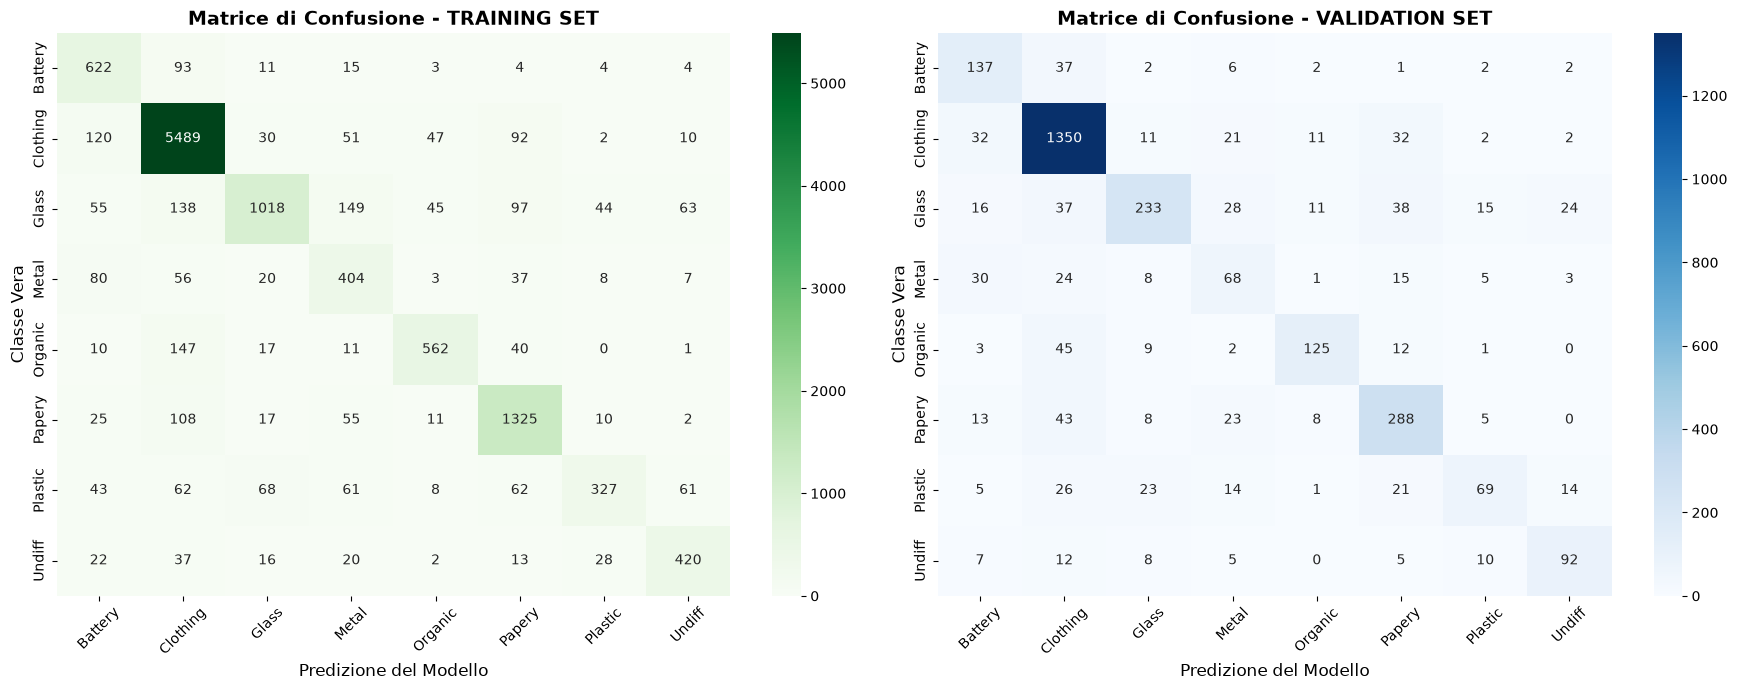


🔍 Ricerca delle immagini classificate in modo errato nel Validation Set...
❌ Trovati 741 errori totali sul Validation.
Mostro i primi 4 errori più clamorosi:



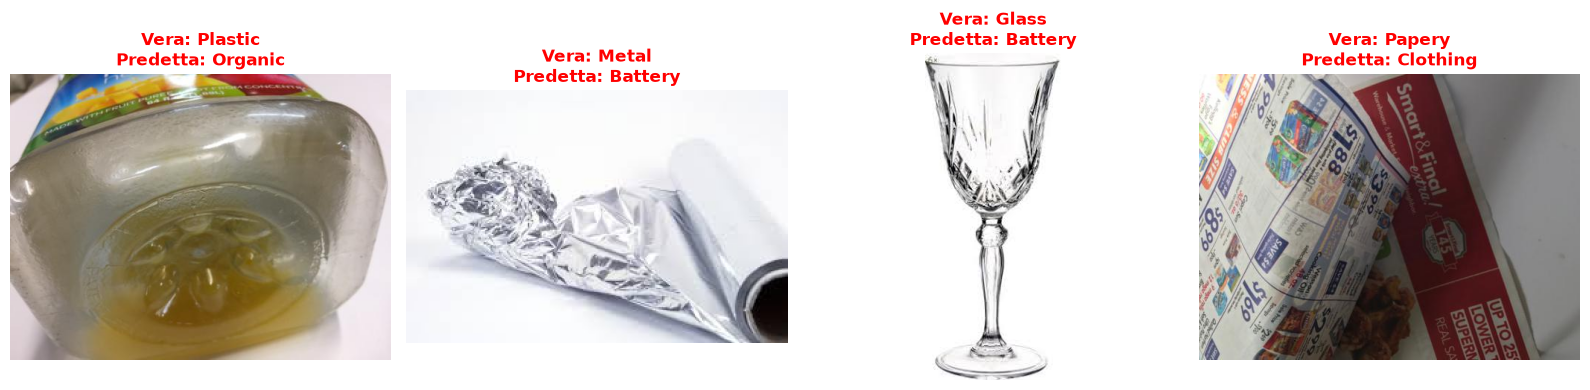

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from PIL import Image

print("🚀 MIVIA DAY 2: Testing, Metriche e Analisi Errori (Train vs Validation) 🚀\n")

# Nomi delle classi per i grafici
class_names = ['Battery', 'Clothing', 'Glass', 'Metal', 'Organic', 'Papery', 'Plastic', 'Undiff']

model.eval()  

# ==========================================
# 1. VALUTAZIONE SUL TRAINING SET
# ==========================================
print("🏋️ Analisi del Training Set in corso...")
# Creiamo un loader per il training senza mischiarlo (shuffle=False) per una valutazione pulita.
# Usiamo 'base_transforms' e 'WasteDataset' esattamente come li hai definiti nella Cella 2!
train_eval_loader = DataLoader(WasteDataset(train_df, transform=base_transforms), batch_size=BATCH_SIZE, shuffle=False)

train_etichette_vere = []
train_etichette_predette = []

# Spegniamo i gradienti per risparmiare memoria
with torch.no_grad():
    for inputs, labels in train_eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        # Estraiamo la classe vincitrice
        _, predicted = torch.max(outputs.data, 1)
        
        train_etichette_vere.extend(labels.cpu().numpy())
        train_etichette_predette.extend(predicted.cpu().numpy())

# ==========================================
# 2. VALUTAZIONE SUL VALIDATION SET
# ==========================================
print("🧪 Analisi del Validation Set in corso...")
val_etichette_vere = []
val_etichette_predette = []
    
with torch.no_grad():
    for inputs, labels in val_loader: # Questo è il tuo val_loader originale
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
            
        val_etichette_vere.extend(labels.cpu().numpy())
        val_etichette_predette.extend(predicted.cpu().numpy())

# ==========================================
# 3. CALCOLO METRICHE UFFICIALI (Prof)
# ==========================================
# Metriche per il Training Set
train_accuracy_bal = balanced_accuracy_score(train_etichette_vere, train_etichette_predette)
train_matrice_conf = confusion_matrix(train_etichette_vere, train_etichette_predette)

# Metriche per il Validation Set
val_accuracy_bal = balanced_accuracy_score(val_etichette_vere, val_etichette_predette)
val_matrice_conf = confusion_matrix(val_etichette_vere, val_etichette_predette)
    
print(f"\n✅ Esame completato!")
print(f"🔹 Immagini Train analizzate: {len(train_etichette_vere)}")
print(f"🔹 Immagini Validation analizzate: {len(val_etichette_vere)}")
print("-" * 40)
print(f"🏆 BALANCED ACCURACY TRAIN:      {train_accuracy_bal * 100:.2f}%") 
print(f"🏆 BALANCED ACCURACY VALIDATION: {val_accuracy_bal * 100:.2f}%") 
print("-" * 40)

# ==========================================
# 4. MATRICI DI CONFUSIONE VISUALI (HEATMAP)
# ==========================================
# Creiamo una figura larga per contenere due grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafico 1: Mappa del Training (Sinistra, in Verde)
sns.heatmap(train_matrice_conf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matrice di Confusione - TRAINING SET', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predizione del Modello', fontsize=12)
axes[0].set_ylabel('Classe Vera', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Grafico 2: Mappa del Validation (Destra, in Blu)
sns.heatmap(val_matrice_conf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matrice di Confusione - VALIDATION SET', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predizione del Modello', fontsize=12)
axes[1].set_ylabel('Classe Vera', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# 5. ANALISI DEGLI ERRORI (Sul Validation)
# ==========================================
print("\n🔍 Ricerca delle immagini classificate in modo errato nel Validation Set...")

# Troviamo gli indici dove la predizione è diversa dalla verità
indici_errori = [i for i in range(len(val_etichette_vere)) if val_etichette_vere[i] != val_etichette_predette[i]]

print(f"❌ Trovati {len(indici_errori)} errori totali sul Validation.")

if len(indici_errori) > 0:
    print("Mostro i primi 4 errori più clamorosi:\n")
    # Resettiamo l'indice del dataframe per assicurarci che corrisponda alla lista
    val_df_reset = val_df.reset_index(drop=True)
    
    # Mostriamo massimo 4 immagini
    fig, axes = plt.subplots(1, min(4, len(indici_errori)), figsize=(16, 4))
    if len(indici_errori) == 1: axes = [axes] # Gestione caso singolo errore
    
    for ax, idx in zip(axes, indici_errori[:4]):
        img_path = val_df_reset.iloc[idx]['filepath']
        vera_label = class_names[val_etichette_vere[idx]]
        pred_label = class_names[val_etichette_predette[idx]]
        
        # Carichiamo e mostriamo l'immagine
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Vera: {vera_label}\nPredetta: {pred_label}", 
                     color='red' if vera_label != pred_label else 'green',
                     fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# OPZIONALE: Memoria (Misurata solo per le GPU compatibili)
if torch.cuda.is_available():
    vram_usata = torch.cuda.max_memory_allocated() / (1024 * 1024)
    print(f"\n💻 VRAM massima usata in fase di Test: {vram_usata:.2f} MB")